# 项目：在线词典

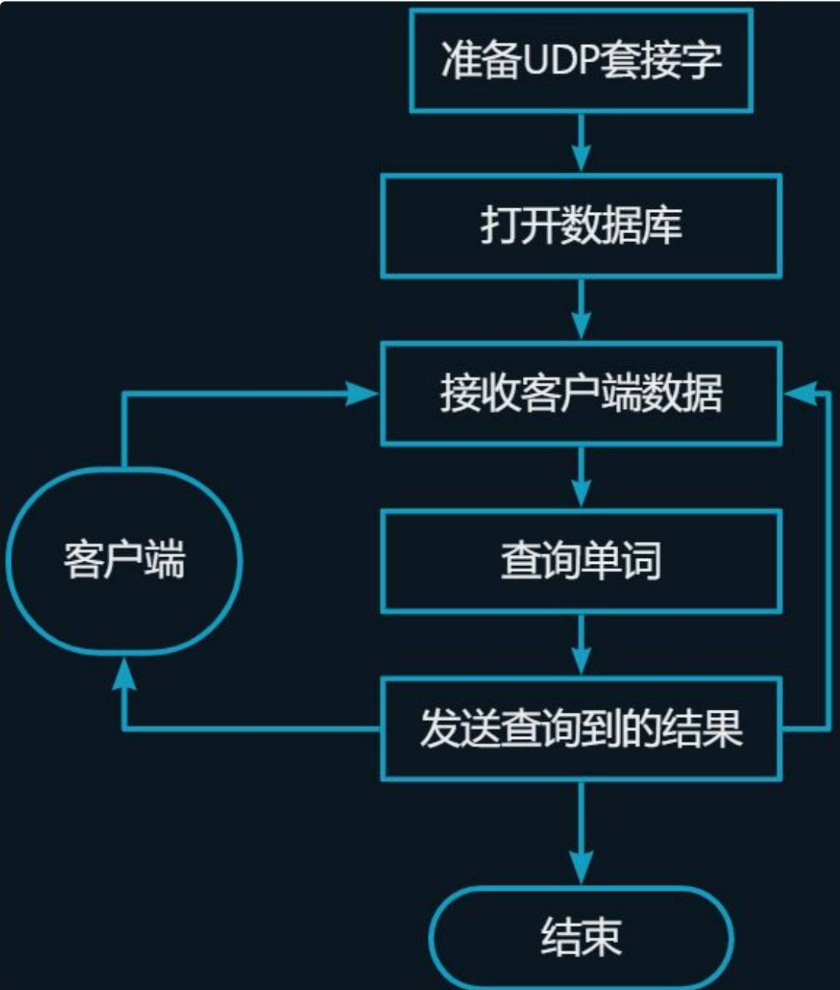

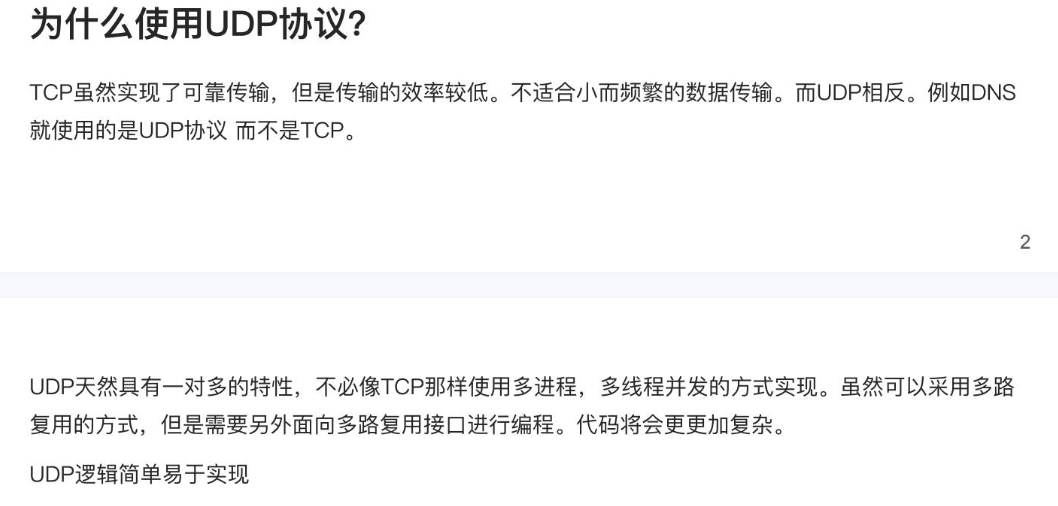

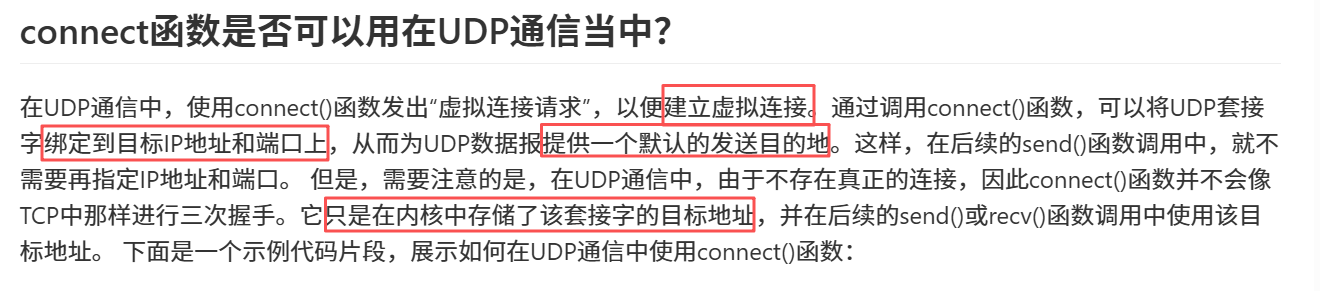

In [ ]:
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <netinet/in.h>
#include <sys/socket.h>

#define BUF_SIZE 1024

int main(int argc, char *argv[]) {
    if (argc != 3) {
        printf("Usage: %s <IP> <port>\n", argv[0]);
        exit(1);
    }

    int sockfd = socket(AF_INET, SOCK_DGRAM, 0);
    if (sockfd == -1) {
        perror("socket");
        exit(1);
    }

    struct sockaddr_in dest_addr;
    memset(&dest_addr, 0, sizeof(dest_addr));
    dest_addr.sin_family = AF_INET;
    dest_addr.sin_addr.s_addr = inet_addr(argv[1]);
    dest_addr.sin_port = htons(atoi(argv[2]));

    if (connect(sockfd, (struct sockaddr *)&dest_addr, sizeof(dest_addr)) == -1) {
        perror("connect");
        exit(1);
    }

    char buf[BUF_SIZE];
    printf("Enter message: ");
    fgets(buf, BUF_SIZE, stdin);

    if (send(sockfd, buf, strlen(buf), 0) == -1) {
        perror("send");
        exit(1);
    }

    close(sockfd);
    return 0;
}
